# Data Understanding

## 1. Tujuan Dataset

AsphaltPavementType adalah dataset time series classification untuk mengindentifikasi jenis permukaan jalan berdasarkan getaran/percepatan yang direkam oleh accelerometer smartphone saat kendaraan berjalan. Target klasifikasinya adalah membedakan 3 tipe jalan: flexible pavement (aspal), cobblestone street (batu/paving), dan dirt road (tanah).

## 2. Sumber data & skenario pengambilan (data collection)

- Smartphone dipasang di dalam kendaraan menggunakan flexible suction holder dekat dashboard.
- Pengemudi adalah expert yang menjalankan aplikasi Android Asfault dengan memanfaatkan sensor Accelerometer yang ada di Smartphone untuk merepak sinyal percepatan selama berkendara.
- Asfault menyimpan beberapa sinyal/rekaman: timestamp, percepatan sumbu (X, Y, Z), serta data GPS seperti latitude, longitude, dan velocity; aplikasi juga merekam video jalan untuk menjaga integritas label.
- Pengambilan dilakukan di beberapa kota di Brasil: São Carlos, Ribeirão Preto, Araraquara, dan Maringá, menggunakan mobil hatchback Hyundai i30, dan dua tipe device: Samsung Galaxy A5 dan Samsung S7.

## 3. Sensor & variabel yang tersedia

### 3.1 Variabel mentah yang direkam

- Accelerometer 3-sumbu: menghasilkan deret waktu 𝐴𝑥(𝑡), 𝐴𝑦(𝑡), 𝐴𝑧(𝑡) yaitu percepatan dalam tiga arah tegak lurus.
- GPS: latitude, longitude, velocity untuk memetakan lokasi segmen/hasil klasifikasi.
- Video untuk audit/konfirmasi label.

### 3.2 Sampling Rate

- Sampling rate yang ditargetkan sekitar 100 Hz, tetapi Android tidak menjamin interval yang benar-benar presisi, sehingga output real bisa sekitar 95–105 observasi/detik.

## 4. Transformasi data untuk klasifikasi: dari 3-sumbu → 1-sinyal (acceleration magnitude)

Walaupun perekaman awal menghasilkan 𝐴𝑥, 𝐴𝑦, 𝐴𝑧, pada versi dataset ini sinyal tersebut dikompresi menjadi univariate time series berupa magnitudo percepatan 𝐴𝑚(𝑡)

Magnitudo dihitung sebagai:

$$ mag(t) = \sqrt{Ax(t)^2 + Ay(t)^2 + Az(t)^2}$$

Lalu gravitasi/offset dihapus dengan mengurangkan rata-rata:

$$ A_m(t) = \text{mag}(t) - \text{mean}(\text{mag}) $$

magnitudo merepresentasikan “kekuatan getaran total” dan cenderung lebih stabil terhadap perubahan orientasi sumbu (dibanding memaksa model belajar dari 3 arah yang bisa bergeser karena kemiringan pemasangan perangkat). Ini sejalan dengan tujuan preprocessing agar sinyal lebih invariant terhadap inclination perangkat.

## 5. Segmentasi

Untuk dataset Asphalt-PavType, data direkam dalam jarak sangat panjang (lebih dari 100 km secara total; sekitar 63 km untuk PavType), sehingga perlu dipotong menjadi segmen-segmen kecil agar:

1. bisa dievaluasi sebagai "banyak contoh data", dan
2. bisa menunjukkan lokasi masalah/jenis jalan pada peta. 

menggunakan panjang segmen sekitar 30 meter per contoh.

**Cara menentukan batas segmen 30 m**

Karena sampling rate bervariasi (95–105 Hz), mereka tidak memotong berdasarkan jumlah sampel yang fixed. Sebaliknya, mereka menjumlahkan jarak kecil per sampel:

$$ \Delta s \approx \frac{v}{f_s} $$

lalu akumulasi sampai mendekati 30 m, baru dipotong jadi 1 segmen. 

## 6. Distribusi kelas

Distribusi kelas (total 1319 contoh) adalah:

- Flexible pavement: 503 contoh
- Cobblestone: 491 contoh
- Dirt road: 325 contoh

## 7. Gambaran data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Datasets/AsphaltPavementType_combine.csv")
df

,TimeSeriesData_0,TimeSeriesData_1,TimeSeriesData_2,TimeSeriesData_3,TimeSeriesData_4,TimeSeriesData_5,TimeSeriesData_6,TimeSeriesData_7,TimeSeriesData_8,TimeSeriesData_9,...,TimeSeriesData_2362,TimeSeriesData_2363,TimeSeriesData_2364,TimeSeriesData_2365,TimeSeriesData_2366,TimeSeriesData_2367,TimeSeriesData_2368,TimeSeriesData_2369,TimeSeriesData_2370,ClassLabel
0,-2.876570,1.663488,-4.498386,3.488434,0.395251,-3.587129,0.773357,-0.915250,2.573000,1.361841,...,-0.053895,0.036566,-0.031380,0.075436,-0.011254,-0.049133,0.024650,-0.054421,0.021338,cobblestone
1,-0.701747,-0.570766,0.566515,-0.218081,1.199675,2.872561,1.940022,-2.274027,1.609701,4.039853,...,-0.032685,-0.029768,-0.018517,0.107980,0.081965,0.092394,0.068861,-0.019790,0.017132,cobblestone
2,4.369829,-3.141377,3.529192,2.660682,2.462394,-1.882157,0.104404,0.942166,1.283458,-3.968304,...,0.472872,0.495197,0.335800,0.503290,0.559216,0.552964,0.396256,0.528568,0.570236,cobblestone
3,8.916818,-3.653964,-3.222407,5.952949,-2.532802,-1.536643,2.157628,0.213207,-0.088351,2.634485,...,0.084240,-0.015055,0.062965,-0.027785,0.127377,0.109734,0.051033,0.078114,0.051622,cobblestone
4,2.233004,0.050001,-2.284447,-1.813584,2.641198,-1.083767,2.177665,-0.227288,-1.730810,1.752036,...,0.023642,-0.023909,-0.093946,0.022844,0.023458,0.025328,-0.062764,-0.055489,-0.072873,cobblestone
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1314,0.880715,-2.346590,-2.329858,2.212091,-1.166301,0.371006,1.442045,-0.190440,-0.507736,-0.681386,...,-0.006118,-0.051817,-0.063536,-0.083512,-0.070412,-0.032090,-0.011215,-0.103924,0.003740,dirt
1315,-0.725810,0.307290,-0.665848,0.014449,0.020445,-0.815619,-0.315867,0.660846,-0.794393,0.261320,...,-0.030569,-0.018032,-0.018122,0.009309,-0.002325,-0.004623,-0.030401,-0.018509,0.006401,flexible
1316,6.432972,-0.184155,-4.374001,-0.011607,-1.068614,4.028121,2.998381,-3.004130,2.899988,-0.824554,...,-0.036395,-0.132641,-0.009433,-0.154533,-0.064270,-0.051793,-0.099983,-0.039613,-0.086337,cobblestone
1317,-0.416838,2.559118,-1.690034,-0.278789,0.573216,0.116075,-0.407203,1.595101,-4.097763,1.875713,...,-0.007052,-0.006644,-0.037258,-0.027634,-0.019115,0.009543,-0.076739,0.016153,0.008333,dirt


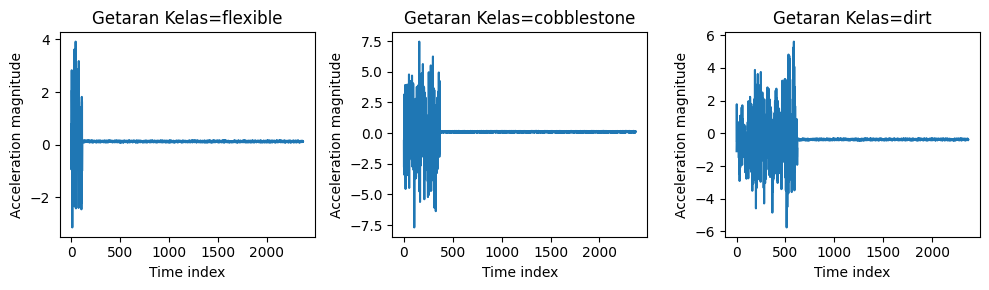

In [17]:
X_arr = df.drop(columns=['ClassLabel']).to_numpy(dtype=float)
y = df['ClassLabel']

out_idx = [700, 50, 500]
sample_idx = out_idx

rows, cols = 1, 3 

fig, axes = plt.subplots(rows, cols, figsize=(10, 3))

for ax, i in zip(axes.ravel(), sample_idx):
    ax.plot(X_arr[i])
    ax.set_title(f"Getaran Kelas={y.iloc[i]}")
    ax.set_xlabel("Time index")
    ax.set_ylabel("Acceleration magnitude")

plt.tight_layout()
plt.show()


## Eksplorasi Data

### 1. Informasi Dasar Data

In [2]:
print("=== HEAD DATA ===")
print(df.head())

print("\n=== INFO DATA ===")
print(df.info())

print("\n=== DESKRIPSI STATISTIK (ringkas, 5 kolom pertama) ===")
print(df.describe().iloc[:, :5])

=== HEAD DATA ===
   TimeSeriesData_0  TimeSeriesData_1  TimeSeriesData_2  TimeSeriesData_3  \
0         -2.876570          1.663488         -4.498386          3.488434   
1         -0.701747         -0.570766          0.566515         -0.218081   
2          4.369829         -3.141377          3.529192          2.660682   
3          8.916818         -3.653964         -3.222407          5.952949   
4          2.233004          0.050001         -2.284447         -1.813584   

   TimeSeriesData_4  TimeSeriesData_5  TimeSeriesData_6  TimeSeriesData_7  \
0          0.395251         -3.587129          0.773357         -0.915250   
1          1.199675          2.872561          1.940022         -2.274027   
2          2.462394         -1.882157          0.104404          0.942166   
3         -2.532802         -1.536643          2.157628          0.213207   
4          2.641198         -1.083767          2.177665         -0.227288   

   TimeSeriesData_8  TimeSeriesData_9  ...  TimeSeriesDa

### 2. Missing Value


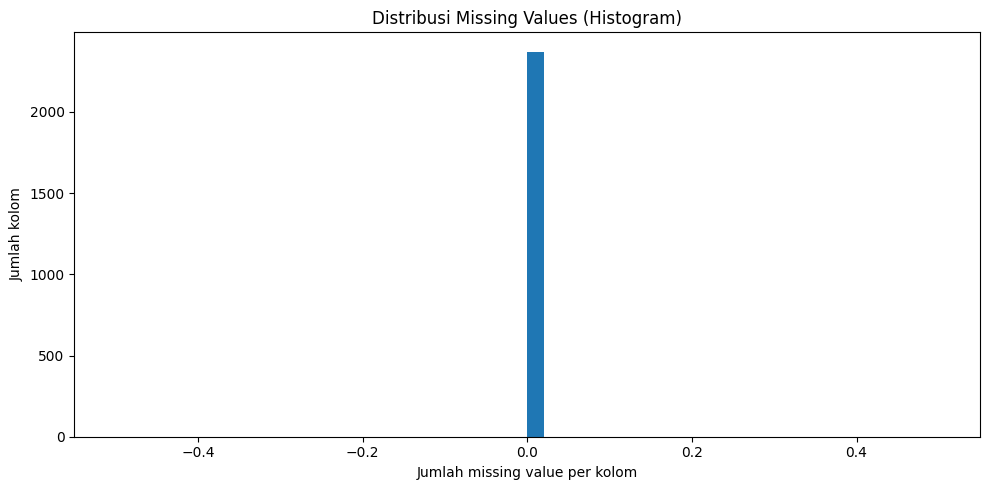

In [3]:
missing = df.isna().sum()

plt.figure(figsize=(10,5))
plt.hist(missing, bins=50)
plt.xlabel("Jumlah missing value per kolom")
plt.ylabel("Jumlah kolom")
plt.title("Distribusi Missing Values (Histogram)")
plt.tight_layout()
plt.show()

### 2. Tipe data

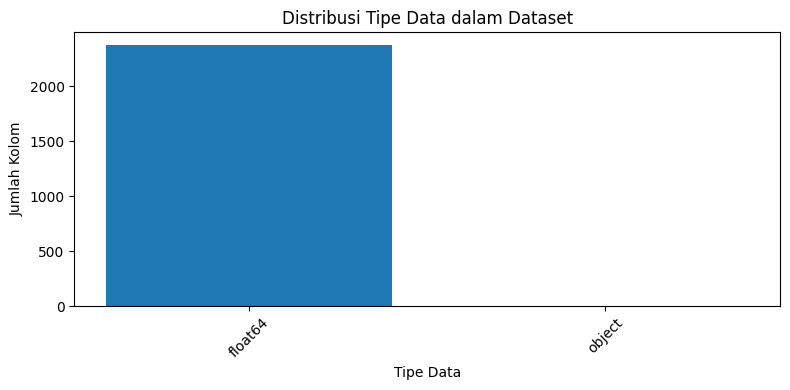

In [4]:
dtype_counts = df.dtypes.value_counts()

plt.figure(figsize=(8, 4))
plt.bar(dtype_counts.index.astype(str), dtype_counts.values)
plt.xlabel("Tipe Data")
plt.ylabel("Jumlah Kolom")
plt.title("Distribusi Tipe Data dalam Dataset")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3. Distribusi Label/Class

ClassLabel
flexible       503
dirt           491
cobblestone    325
Name: count, dtype: int64


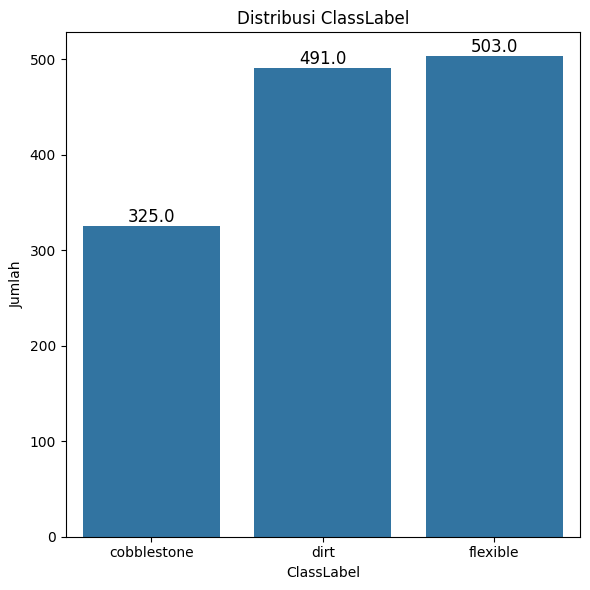

In [5]:

class_counts = df["ClassLabel"].value_counts()

print(class_counts)

plt.figure(figsize=(6,6))
ax = sns.countplot(x=df["ClassLabel"])

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}',
                (p.get_x() + p.get_width()/2., height),
                ha='center', va='bottom', fontsize=12)

plt.title("Distribusi ClassLabel")
plt.xlabel("ClassLabel")
plt.ylabel("Jumlah")
plt.tight_layout()
plt.show()

### 4. Duplikasi Data

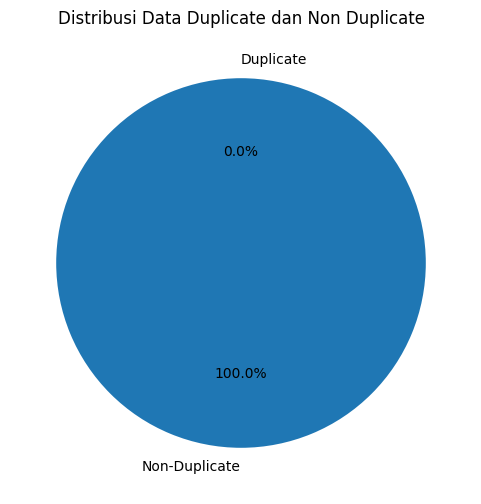

In [6]:
duplicates = df.duplicated().sum()
non_duplicates = len(df) - duplicates

labels = ['Non-Duplicate', 'Duplicate']
values = [non_duplicates, duplicates]

plt.figure(figsize=(6, 6))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Distribusi Data Duplicate dan Non Duplicate")
plt.show()

### 5. Deteksi Outlier

In [7]:
X = df.drop(columns=['ClassLabel'])
y = df['ClassLabel']
X_desc = X.describe()
print(X_desc.loc[['min', 'max', 'mean', 'std']])

      TimeSeriesData_0  TimeSeriesData_1  TimeSeriesData_2  TimeSeriesData_3  \
min          -7.512546         -8.523067         -8.998474         -9.244137   
max          11.101545          9.942422          9.109397          8.321178   
mean          0.007146         -0.002606         -0.082418         -0.142575   
std           2.079385          2.031884          1.962595          2.141794   

      TimeSeriesData_4  TimeSeriesData_5  TimeSeriesData_6  TimeSeriesData_7  \
min          -8.882876         -9.092468         -9.007875         -7.980434   
max          25.806197         15.908705          8.933173         11.176892   
mean          0.022140          0.012053         -0.032798          0.007534   
std           2.317607          2.197334          2.066168          2.039411   

      TimeSeriesData_8  TimeSeriesData_9  ...  TimeSeriesData_2361  \
min          -7.984612         -7.113500  ...            -0.441485   
max          15.543681         11.548522  ...             

In [8]:
X_arr = X.to_numpy(dtype=float)

row_max = X_arr.max(axis=1)
row_min = X_arr.min(axis=1)
row_std = X_arr.std(axis=1)
row_mean = X_arr.mean(axis=1)
print(pd.Series(row_max).describe())
print(pd.Series(row_std).describe())



count    1319.000000
mean        7.236235
std         4.480004
min         1.230292
25%         3.271269
50%         6.893314
75%        10.057863
max        58.054914
dtype: float64
count    1319.000000
mean        0.814430
std         0.464988
min         0.171744
25%         0.321558
50%         0.848287
75%         1.148016
max         2.065046
dtype: float64


In [9]:
upper = 20.24 
out_idx = np.where(row_max > upper)[0]
print("Jumlah kandidat outlier:", len(out_idx))
print("Index contoh:", out_idx)

Jumlah kandidat outlier: 9
Index contoh: [  27   31  172  284  431  625 1073 1148 1259]


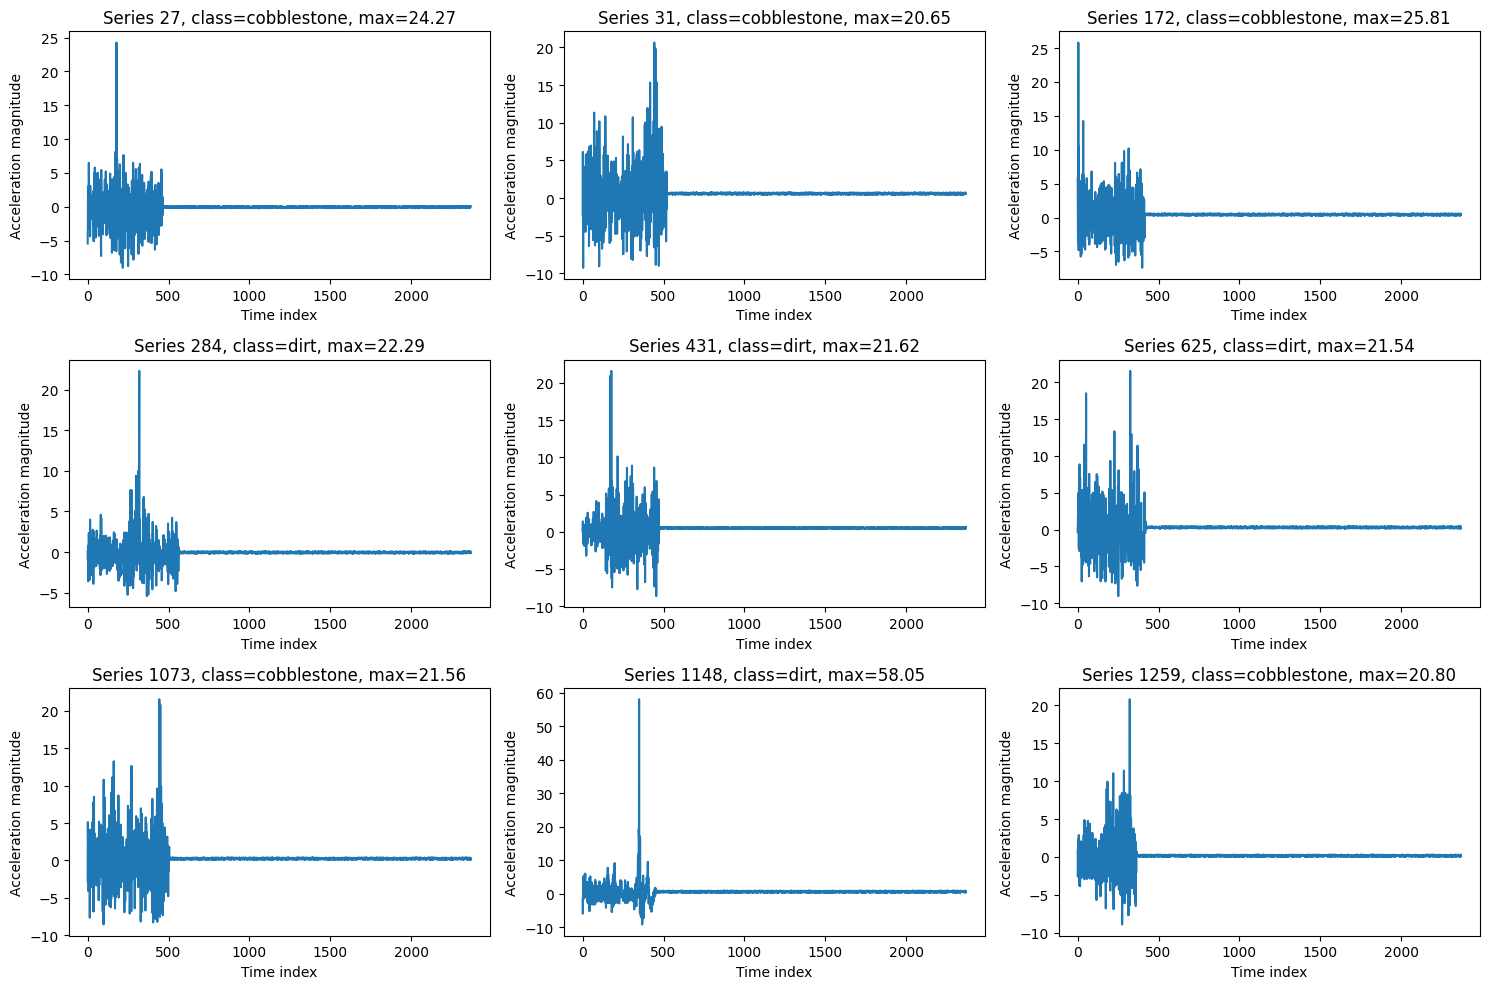

In [10]:
sample_idx = out_idx[:9]

rows, cols = 3, 3 

fig, axes = plt.subplots(rows, cols, figsize=(15, 10))

for ax, i in zip(axes.ravel(), sample_idx):
    ax.plot(X_arr[i])
    ax.set_title(f"Series {i}, class={y.iloc[i]}, max={row_max[i]:.2f}")
    ax.set_xlabel("Time index")
    ax.set_ylabel("Acceleration magnitude")

plt.tight_layout()
plt.show()
